In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread("raw_captures/document.jpeg")

In [4]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

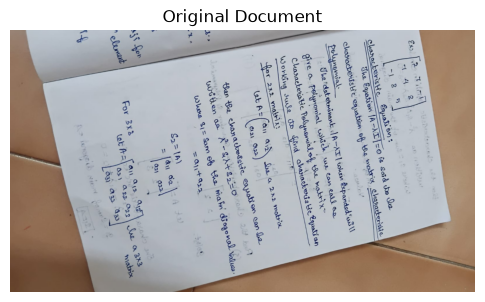

In [5]:
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Original Document")
plt.axis("off")
plt.show()

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

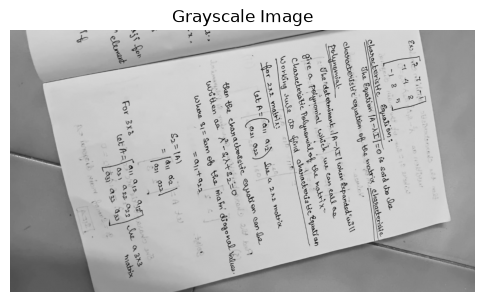

In [7]:
plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [8]:
ret, otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

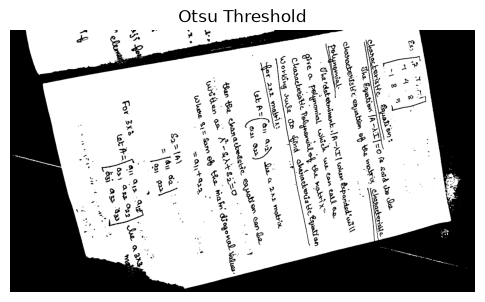

In [9]:
plt.figure(figsize=(6,6))
plt.imshow(otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")
plt.show()

In [10]:
kernel = np.ones((3,3), np.uint8)
closing = cv2.morphologyEx(
    otsu,
    cv2.MORPH_CLOSE,
    kernel
)

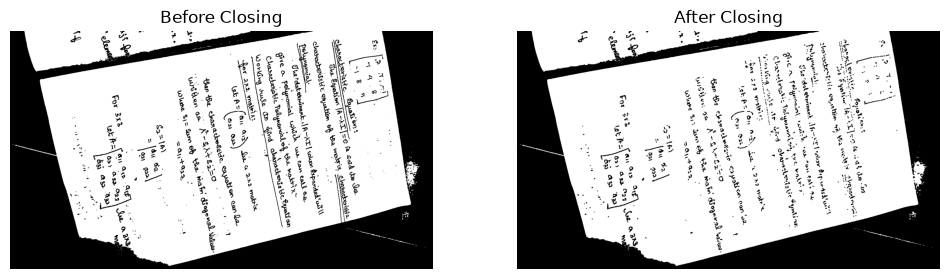

In [11]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(otsu, cmap="gray")
plt.title("Before Closing")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(closing, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.show()

In [12]:
crop_before = otsu[250:350, 150:450]

crop_after = closing[250:350, 150:450]

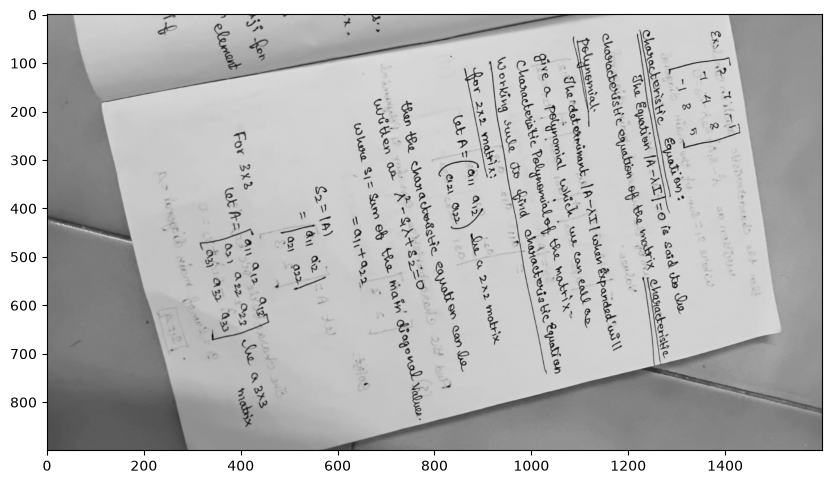

In [13]:
plt.figure(figsize=(10,10))
plt.imshow(gray, cmap="gray")
plt.axis("on")
plt.show()

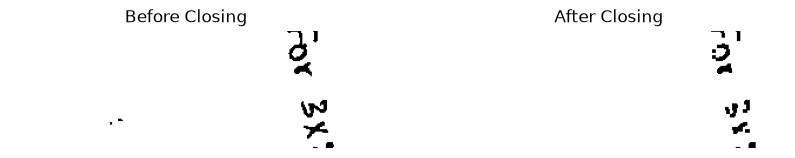

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(crop_before, cmap="gray")
plt.title("Before Closing")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop_after, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.show()

In [15]:
kernel2 = np.ones((2,2), np.uint8)

close2 = cv2.morphologyEx(
    otsu,
    cv2.MORPH_CLOSE,
    kernel2
)

In [16]:
kernel3 = np.ones((3,3), np.uint8)

close3 = cv2.morphologyEx(
    otsu,
    cv2.MORPH_CLOSE,
    kernel3
)

In [17]:
kernel5 = np.ones((5,5), np.uint8)

close5 = cv2.morphologyEx(
    otsu,
    cv2.MORPH_CLOSE,
    kernel5
)

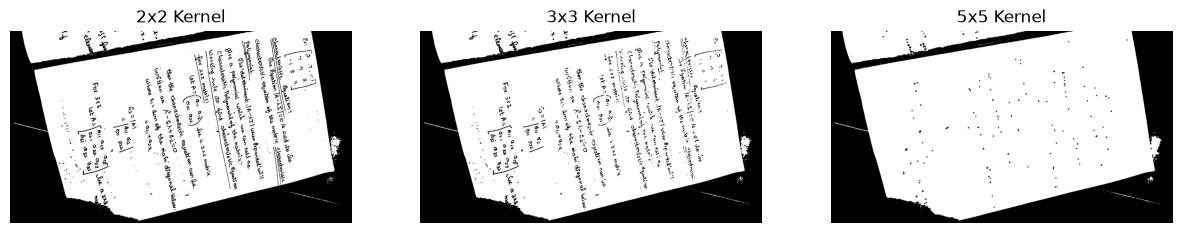

In [18]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(close2, cmap="gray")
plt.title("2x2 Kernel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(close3, cmap="gray")
plt.title("3x3 Kernel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(close5, cmap="gray")
plt.title("5x5 Kernel")
plt.axis("off")

plt.show()

Observation

Otsu's thresholding automatically converted the handwritten document into a binary image by selecting an appropriate threshold value.After thresholding, morphological closing was applied using a 3×3 kernel.
The 3×3 kernel worked best because it filled small gaps in the handwritten letters while preserving their overall shape.A smaller kernel (2×2) did not remove all the small gaps, whereas a larger kernel (5×5) caused some nearby letters to merge together and reduced the clarity of the handwriting.This choice was appropriate for my document image because the handwritten text was of medium size and the image resolution was sufficient for a 3×3 kernel to clean the text without excessive distortion.